In [2]:
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import random
import cv2
import os
import albumentations as A

In [3]:
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
!curl -L -o deepglobe-road-extraction-dataset.zip https://www.kaggle.com/api/v1/datasets/download/balraj98/deepglobe-road-extraction-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 3885M  100 3885M    0     0   179M      0  0:00:21  0:00:21 --:--:--  223M


In [11]:
data_path = "./data"
model_path = "./models"
os.makedirs(data_path, exist_ok=True)
os.makedirs(model_path, exist_ok=True)

In [ ]:
!unzip ./deepglobe-road-extraction-dataset.zip -d data

In [13]:
Params = {
    "img_size": 640,
    "batch_size": 8,
    "num_classes": 1,
    "num_epochs": 100,
    "learning_rate": 0.001,
    "decay_rate": 0.1,
    "val_pct": 0.1,
    "seed": 42,
}

In [14]:
metadata = pd.read_csv("./data/metadata.csv")

In [15]:
np.random.seed(Params["seed"])
random.seed(Params["seed"])

In [16]:
metadata.head()

,image_id,split,sat_image_path,mask_path
0,100034,train,train/100034_sat.jpg,train/100034_mask.png
1,100081,train,train/100081_sat.jpg,train/100081_mask.png
2,100129,train,train/100129_sat.jpg,train/100129_mask.png
3,100703,train,train/100703_sat.jpg,train/100703_mask.png
4,100712,train,train/100712_sat.jpg,train/100712_mask.png


In [17]:
metadata.isna().sum()

image_id             0
split                0
sat_image_path       0
mask_path         2344
dtype: int64

In [18]:

def get_pairs(metadata:pd.DataFrame) -> list:
    data = metadata[metadata["mask_path"].notna()]
    return list(zip(data["sat_image_path"], data["mask_path"]))

pairs = get_pairs(metadata)

np.random.shuffle(pairs)
val_num = int(np.size(pairs) * Params["val_pct"])
train_data = pairs[:1-val_num]
val_data = pairs[1-val_num:]


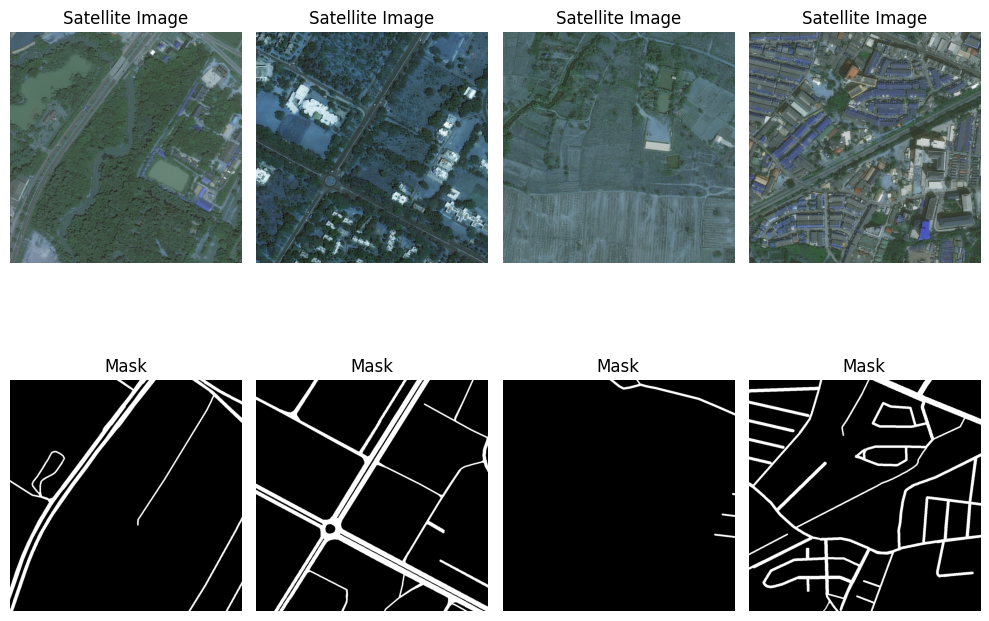

In [19]:
fig, ax = plt.subplots(2,4, figsize=(10,8))
for i in range(4):
    sat_img = cv2.imread(os.path.join(data_path, train_data[i][0]))
    ax[0][i].imshow(sat_img)
    ax[0][i].set_title("Satellite Image")
    ax[0][i].axis("off")

    mask_img = cv2.imread(os.path.join(data_path, train_data[i][1]))
    ax[1][i].imshow(mask_img)
    ax[1][i].set_title("Mask")
    ax[1][i].axis("off")

plt.tight_layout()
plt.show()

In [20]:
class DataLoader():
    def __init__(self, pairs:tuple , data_dir:str = "./data", img_size: int = 384, split: str = "train"):
        self.data_folder = data_dir
        self.pairs = pairs
        self.transform = self._build_tranformer(split, img_size)

    def _build_tranformer(self, split, img_size):
        mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
        if split == "train":

            transform = A.Compose([
                A.Resize(img_size, img_size),
                A.RandomRotate90(p=0.4),
                A.VerticalFlip(p=0.4),
                A.HorizontalFlip(p=0.3),
                A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.25),
                A.CoarseDropout(max_holes=6,max_height=img_size//12,max_width=img_size//12, p=0.4),
                A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.25),
                A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=15,p=0.3),
                A.CLAHE(p=1, clip_limit=8),
                A.Normalize(mean=mean, std=std),
            ])
        else :
            transform = A.Compose([
                A.Resize(img_size, img_size),
                A.CLAHE(p=1, clip_limit=8),
                A.Normalize(mean=mean, std=std),
            ])

        return transform

    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        sat_path, mask_path = self.pairs[idx]
        img = cv2.imread(os.path.join(self.data_folder,sat_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(os.path.join(self.data_folder, mask_path), cv2.IMREAD_GRAYSCALE)
        aug = self.transform(image=img, mask=mask)
        return aug["image"], aug["mask"]

    def get_labels(self):
        return [p[1] for p in self.pairs]



train_dl = DataLoader(pairs=train_data, img_size=Params["img_size"])
val_dl = DataLoader(pairs=val_data, img_size=Params["img_size"], split="val")



C:\Users\Administrator\AppData\Local\Temp\ipykernel_9784\686039022.py:17: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=6,max_height=img_size//12,max_width=img_size//12, p=0.4),
C:\Users\Administrator\AppData\Roaming\Python\Python310\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.5877123].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5005665].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


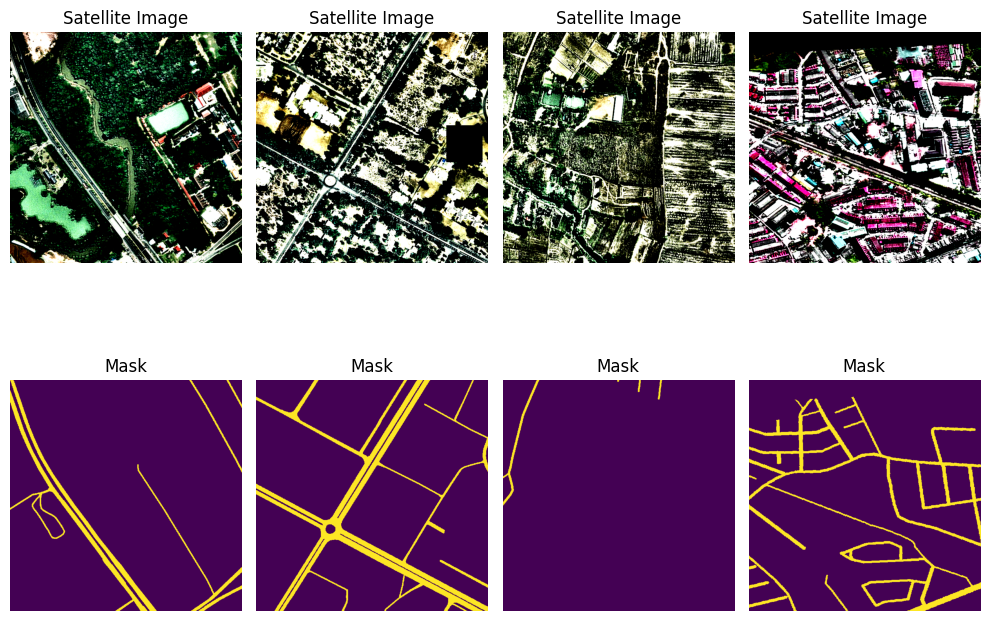

In [21]:
fig, ax = plt.subplots(2,4, figsize=(10,8))
for i in range(4):
    sat_img, mask = train_dl[i]
    ax[0][i].imshow(sat_img)
    ax[0][i].set_title("Satellite Image")
    ax[0][i].axis("off")

    ax[1][i].imshow(mask)
    ax[1][i].set_title("Mask")
    ax[1][i].axis("off")

plt.tight_layout()
plt.show()

plt.show()

In [22]:
np.unique(mask)

array([  0, 255], dtype=uint8)

In [23]:
from tensorflow import keras
from keras.layers import Conv2DTranspose, Concatenate, Conv2D, BatchNormalization, Activation, Add
from keras.models import Sequential

from keras.applications.efficientnet import preprocess_input

In [24]:
keras.backend.set_image_data_format("channels_last")

In [25]:
class MultiScaleAttention(keras.layers.Layer):
    def __init__(self, F_int):
        super().__init__()
        self.w_x = Sequential([
            Conv2D(F_int, use_bias=False, kernel_size=1, padding="same"),
            BatchNormalization(),
        ])
        self.w_g = Sequential([
            Conv2D(F_int, use_bias=False, kernel_size=1, padding="same"),
            BatchNormalization(),
        ])

        self.local_branch = Sequential([
            Conv2D(F_int, use_bias=False, kernel_size=1, padding="same"),
            BatchNormalization(),
        ])
        self.mid_branch = Sequential([
            Conv2D(F_int, use_bias=False, kernel_size=3, padding="same"),
            BatchNormalization(),
        ])
        self.dilated_branch = Sequential([
            Conv2D(F_int, use_bias=False, kernel_size=3, padding="same", dilation_rate=3),
            BatchNormalization(),
        ])

        self.fuse = Activation("relu")
        self.fuse_scale = Sequential([
            Conv2D(F_int, padding="same", kernel_size=1, use_bias=False),
            BatchNormalization(),
            Activation("relu")
        ])
        self.psi = Sequential([
            Conv2D(1, use_bias=False, kernel_size=1, padding="same"),
            BatchNormalization(),
            Activation("sigmoid")
        ])

    def call(self, g, x):  # gating signal, skip
        g = tf.image.resize(g, (tf.shape(x)[1], tf.shape(x)[2]))
        w_x = self.w_x(x)
        w_g = self.w_g(g)
        fused = self.fuse(Add()([w_x, w_g]))     
        multi_scale = tf.concat([
                self.local_branch(fused), self.mid_branch(fused), self.dilated_branch(fused)], axis=-1
        )
        fused_scales = self.fuse_scale(multi_scale)
        attention = self.psi(fused_scales)

        return x * attention



class DecoderBlock(keras.layers.Layer):
    def __init__(self, out_ch):
        super().__init__()
        self.up = Conv2DTranspose(out_ch, strides=2, kernel_size=2, padding="same")
        self.attention = MultiScaleAttention(F_int=out_ch)
        self.conv = Sequential([
            Conv2D(out_ch, kernel_size=3, padding="same", use_bias=False),
            BatchNormalization(),
            Activation("relu"),
            Conv2D(out_ch, kernel_size=3, padding="same", use_bias=False),
            BatchNormalization(),
            Activation("relu")
        ])


    def call(self, x, skip):  # gating signal, skip
        skip = self.attention(x, skip)
        x_up = self.up(x)
        x = Concatenate()([x_up, skip])
        return self.conv(x)



In [26]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from keras.layers import Input

# Load pretrained encoder

input_layer = Input(shape=(Params["img_size"],Params["img_size"],3), name="input_layer")

encoder = tf.keras.applications.EfficientNetB4(
    include_top=False,
    weights="imagenet",
    input_tensor=input_layer,
)

# Skip connections
s1 = encoder.get_layer("block2a_expand_activation").output
s2 = encoder.get_layer("block3a_expand_activation").output
s3 = encoder.get_layer("block4a_expand_activation").output
s4 = encoder.get_layer("block6a_expand_activation").output

bridge = encoder.get_layer("top_activation").output


dec1 = DecoderBlock(out_ch=512)
d1 = dec1(bridge, s4)  # gating signal, skip

dec2 = DecoderBlock(out_ch=256)
d2 = dec2(d1, s3)

dec3 = DecoderBlock(out_ch=128)
d3 = dec3(d2, s2)

dec4 = DecoderBlock(out_ch=64)
d4 = dec4(d3, s1)

outputs = Conv2DTranspose(1, strides=2, kernel_size=2, padding="same", activation="sigmoid")(d4)

model = Model(encoder.input, outputs)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_layer (InputLayer)       [(None, 640, 640, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling (Rescaling)          (None, 640, 640, 3)  0           ['input_layer[0][0]']            
                                                                                                  
 normalization (Normalization)  (None, 640, 640, 3)  7           ['rescaling[0][0]']              
                                                                                                  
 rescaling_1 (Rescaling)        (None, 640, 640, 3)  0           ['normalization[0][0]']      

In [27]:
def tf_generator(dl):
    for i in range(len(dl)):
        img, mask = dl[i]
        img = img.astype(np.float32)
        img = preprocess_input(img)

        if mask.ndim == 2:
            mask = np.expand_dims(mask, -1)
        mask = mask.astype(np.float32) / 255.0
        yield img, mask


In [28]:
train_dataset = tf.data.Dataset.from_generator(lambda: tf_generator(train_dl),
            output_signature=(tf.TensorSpec(shape=(Params["img_size"], Params["img_size"], 3), dtype=tf.float32),
                              tf.TensorSpec(shape=(Params["img_size"], Params["img_size"], 1), dtype=tf.float32))
            ).batch(Params["batch_size"]).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_generator(lambda: tf_generator(val_dl),
            output_signature=(tf.TensorSpec(shape=(Params["img_size"], Params["img_size"], 3), dtype=tf.float32),
                              tf.TensorSpec(shape=(Params["img_size"], Params["img_size"], 1), dtype=tf.float32))
            ).batch(Params["batch_size"]).prefetch(tf.data.AUTOTUNE)

In [29]:
class Mean_IoU(keras.metrics.Metric):
    def __init__(self, threshold=0.5, **kwargs):
        super().__init__(**kwargs)
        self.threshold = threshold
        self.iou_sum = self.add_weight(name="iou_sum", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred > self.threshold, tf.float32)

        intersection = tf.reduce_sum(y_true * y_pred , axis=[1, 2, 3])
        union = (tf.reduce_sum(y_true, axis=[1, 2, 3]) +
                 tf.reduce_sum(y_pred, axis=[1, 2, 3]) - intersection)

        iou_per_sample = (intersection + 1e-7) / (union + 1e-7)
        self.iou_sum.assign_add(tf.reduce_sum(iou_per_sample))
        self.count.assign_add(tf.cast(tf.shape(y_true)[0],tf.float32))

    def reset_state(self):
        self.iou_sum.assign(0.0)
        self.count.assign(0.0)

    def result(self):
        return self.iou_sum / self.count

    def get_config(self):
        return {**super().get_config(), "threshold": self.threshold}

In [30]:
def dice_coef(y_true, y_pred, smooth=1e-7, road_weight=2.0):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred , tf.float32)
    weight = road_weight * y_true + 1.0
    intersection = tf.reduce_sum(weight * y_true * y_pred , axis=[1, 2, 3])
    denominator = tf.reduce_sum(weight * y_true, axis=[1, 2, 3]) + tf.reduce_sum(weight * y_pred, axis=[1, 2, 3])
    dice = (2.0 * intersection + smooth) / (denominator + smooth)
    
    return tf.reduce_mean(dice)


def dice_loss(y_true, y_pred):
    bce = keras.losses.BinaryCrossentropy(from_logits=False)
    bce_loss = bce(y_true, y_pred)
    return 0.5 * bce_loss + 0.5 * (1 - dice_coef(y_true, y_pred))

In [31]:
lr_callback = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_mean__io_u", factor=0.3, patience=4,
                                                   verbose=1, mode="max")
checkpoint = keras.callbacks.ModelCheckpoint("./models/best_model.h5", monitor="val_mean__io_u", verbose=2,
                                             save_best_only=True, mode="max")
EarlyStopping = keras.callbacks.EarlyStopping(monitor="val_mean__io_u", verbose=1, patience=5, mode="max")


In [ ]:
encoder.trainable = False
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss=dice_loss, metrics=[Mean_IoU(name='mean__io_u')])
history = model.fit(train_dataset, validation_data=val_dataset, epochs=10, verbose=2)

In [ ]:
encoder.trainable = True
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss=dice_loss, metrics=[Mean_IoU(name='mean__io_u')])
history = model.fit(train_dataset, validation_data=val_dataset, epochs=50, verbose=2,callbacks=[lr_callback, checkpoint, EarlyStopping])

In [ ]:
model.save("./models/best_model.h5")

In [32]:
model.load_weights("./models/best_model.h5")

1/1 [==============================] - 0s 33ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


1/1 [==============================] - 0s 29ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


1/1 [==============================] - 0s 30ms/step


...

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


1/1 [==============================] - 0s 33ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3410363].


1/1 [==============================] - 0s 32ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


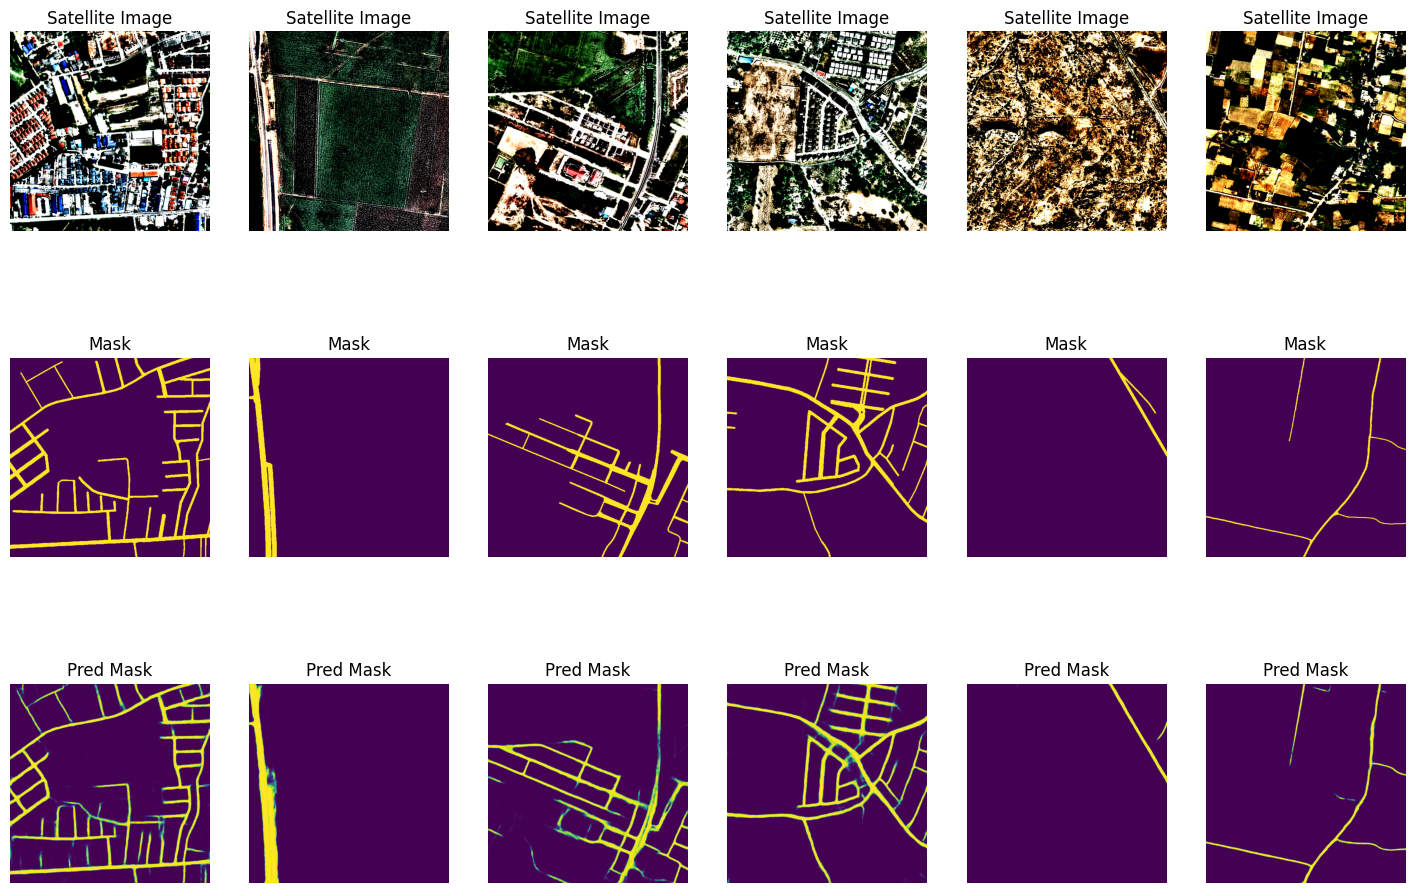

In [57]:

fig, ax = plt.subplots(3,6, figsize=(18,12))
random_imgs = np.random.choice(len(val_dl), size=6, replace=False)
for i, img_idx in enumerate(random_imgs):
    img, mask = val_dl[img_idx]
    processed_img = preprocess_input(img)
    pred = model.predict(np.expand_dims(img,0))

    ax[0][i].imshow(img)
    ax[0][i].set_title("Satellite Image")
    ax[0][i].axis("off")

    ax[1][i].imshow(mask)
    ax[1][i].set_title("Mask")
    ax[1][i].axis("off")


    ax[2][i].imshow(pred[0])
    ax[2][i].set_title("Pred Mask")
    ax[2][i].axis("off")

plt.show()

In [58]:
def calc_IoU(y_pred, y_true, threshold=0.5):
    y_pred = (y_pred > threshold)

    intersection = np.sum(np.logical_and(y_true, y_pred), axis=(1,2,3))
    union = np.sum(np.logical_or(y_true, y_pred), axis=(1,2,3))

    return (intersection + 1e-7) / (union + 1e-7)

In [59]:
def data_generator(dl):
    imgs, masks = [], []
    for i in range(len(dl)):
        img, mask = dl[i]
        img = img.astype(np.float32)
        img = preprocess_input(img)

        if mask.ndim == 2:
            mask = np.expand_dims(mask, -1)
        mask = mask.astype(np.float32) / 255.0
        imgs.append(img)
        masks.append(mask)
    return imgs, masks

In [60]:
imgs, masks = data_generator(val_dl)

In [61]:
pred_masks = []
for img in imgs[:30]:
    mask = model.predict(np.expand_dims(img,0))[0]
    pred_masks.append(mask)

pred_masks = np.array(pred_masks)

1/1 [==============================] - 0s 34ms/step


In [64]:
iou = np.mean(calc_IoU(pred_masks, masks[:30]))
print(f"IoU @ 0.5 : {iou}")

IoU @ 0.5 : 0.5945189347713852
